# Verification: Hlavacek et al. (1999) steric effects models

Verify `#@figure:` claims for the three model variants against an
independent Python/SciPy solution of Eqs. 15-17.

**Figure 8a,b** — Time courses of receptor aggregation:
- **Dotted line**: no steric effects, H(i) = 1 (`_nosteric` variant)
- **Broken line**: Eq. 10 approximate steric hindrance (primary model)
- **Solid line**: combinatoric exact steric hindrance (`_combinatoric` variant)

**Claims verified:**
1. All three BNG models match the independent ODE solution within tolerance
2. Overlay reproduces Fig. 8a (alpha(2)) and Fig. 8b (alpha(10))

In [1]:
import subprocess, os
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

os.chdir(os.path.dirname(os.path.abspath("__file__")))

## Independent implementation of Eqs. 15-17

The dimensionless ODEs from Hlavacek et al. (1999):

$$\frac{dx_i}{d\tau} = u_{i-1} - u_i, \quad i = 1, \ldots, f$$

where $x_i = L_i / R_T$, $\tau = k_{-x} t$, and:

$$u_0 = \frac{k_r}{k_{-x}} \left[ (vKL_T) r \ell - x_1 \right]$$

$$u_i = \nu(i) (K_x R_T) r x_i - (i+1) x_{i+1}, \quad i = 1, \ldots, f-1$$

$$u_f = 0$$

with conservation laws $\ell = 1 - (C R_T / L_T) \sum x_i$ and $r = 1 - \sum i x_i$.

In [2]:
def steric_ode(tau, x, nu_func, params):
    """Eqs. 15-17 in Hlavacek et al. (1999).

    x : array of length f, x[i-1] = x_i for i=1,...,f
    nu_func : callable, nu_func(i) = available sites when i sites bound
    params : dict with vKLT, KxRT, CRT_LT, kr_kmx, f
    """
    f = params["f"]
    vKLT = params["vKLT"]
    KxRT = params["KxRT"]
    CRT_LT = params["CRT_LT"]
    kr_kmx = params["kr_kmx"]

    # Conservation laws (Eqs. 16-17)
    i_vals = np.arange(1, f + 1)
    r = 1.0 - np.dot(i_vals, x)
    l = 1.0 - CRT_LT * np.sum(x)

    # Compute u_i (Eq. 15)
    u = np.zeros(f + 1)
    u[0] = kr_kmx * (vKLT * r * l - x[0])
    for i in range(1, f):
        u[i] = nu_func(i) * KxRT * r * x[i - 1] - (i + 1) * x[i]
    u[f] = 0.0

    # dx_i/dtau = u_{i-1} - u_i
    dxdt = np.zeros(f)
    for i in range(f):
        dxdt[i] = u[i] - u[i + 1]

    return dxdt


def compute_alphas_from_x(x, f):
    """Compute alpha(2) and alpha(10) from x array (Eq. 18)."""
    i_vals = np.arange(1, f + 1)
    r_bound = np.dot(i_vals, x)
    alpha_2 = r_bound - x[0]  # sum(j*x_j, j=2..f)
    alpha_10 = np.dot(i_vals[9:], x[9:])  # sum(j*x_j, j=10..f)
    return alpha_2, alpha_10


# --- Define nu(i) for each case ---

def nu_nosteric(i):
    """No steric effects: nu(i) = n - i."""
    return 20 - i


def nu_eq10(i):
    """Eq. 10 approximation: a/A = 0.01, gamma = 1."""
    n, aA = 20, 0.01
    H = (1 - i * aA) * (1 - 3 * aA / (1 - i * aA)) ** i
    return (n - i) * H


# Combinatoric P_i values from Fig. 7 caption
_Pi = [0.9120, 0.8282, 0.7482, 0.6715, 0.598,
       0.527, 0.458, 0.392, 0.328, 0.265,
       0.205, 0.149, 0.100, 0.062, 0.037,
       0.0216, 0.0119, 0.0060, 0.0024]

def nu_combinatoric(i):
    """Combinatoric exact: nu(i) = n * P_i(A)."""
    if i < 1 or i > 19:
        return 0.0
    return 20 * _Pi[i - 1]


# Shared parameters (Fig. 8 caption)
params = dict(f=20, vKLT=1, KxRT=10, CRT_LT=10, kr_kmx=1)

## Run BNG models and solve independent ODEs

In [3]:
MODELS = {
    "nosteric": {
        "bngl": "steric_effects_ligand_receptor_hlavacek1999_nosteric.bngl",
        "gdat": "steric_effects_ligand_receptor_hlavacek1999_nosteric_ode.gdat",
        "nu": nu_nosteric,
        "label": "No steric (dotted)",
        "style": ":",
    },
    "eq10": {
        "bngl": "steric_effects_ligand_receptor_hlavacek1999.bngl",
        "gdat": "steric_effects_ligand_receptor_hlavacek1999_ode.gdat",
        "nu": nu_eq10,
        "label": "Eq. 10 approx (broken)",
        "style": "--",
    },
    "combinatoric": {
        "bngl": "steric_effects_ligand_receptor_hlavacek1999_combinatoric.bngl",
        "gdat": "steric_effects_ligand_receptor_hlavacek1999_combinatoric_ode.gdat",
        "nu": nu_combinatoric,
        "label": "Combinatoric (solid)",
        "style": "-",
    },
}

f = params["f"]
t_span = (0, 2.5)
t_eval = np.linspace(0, 2.5, 501)
x0 = np.zeros(f)

results = {}
for key, m in MODELS.items():
    # Run BNG
    r = subprocess.run(
        ["bionetgen", "run", "-i", m["bngl"]],
        capture_output=True, text=True,
    )
    assert r.returncode == 0, f"BNG failed for {key}:\n{r.stderr}"
    print(f"BNG {key}: OK")

    # Load BNG output
    bng = np.loadtxt(m["gdat"], comments="#")
    bng_t = bng[:, 0]
    bng_x = bng[:, 1:21]  # Obs_L1 through Obs_L20

    # Compute alpha from BNG observables
    bng_a2 = np.zeros(len(bng_t))
    bng_a10 = np.zeros(len(bng_t))
    for j in range(len(bng_t)):
        bng_a2[j], bng_a10[j] = compute_alphas_from_x(bng_x[j], f)

    # Solve independent ODE
    sol = solve_ivp(
        steric_ode, t_span, x0,
        args=(m["nu"], params),
        t_eval=t_eval,
        method="BDF", rtol=1e-10, atol=1e-12,
    )
    assert sol.success, f"SciPy failed for {key}: {sol.message}"
    print(f"SciPy {key}: OK")

    # Compute alpha from SciPy solution
    py_a2 = np.zeros(len(sol.t))
    py_a10 = np.zeros(len(sol.t))
    for j in range(len(sol.t)):
        py_a2[j], py_a10[j] = compute_alphas_from_x(sol.y[:, j], f)

    # Interpolate SciPy solution at BNG time points for error
    from scipy.interpolate import interp1d
    py_a2_at_bng = interp1d(sol.t, py_a2)(bng_t)
    py_a10_at_bng = interp1d(sol.t, py_a10)(bng_t)

    # Max absolute error
    err_a2 = np.max(np.abs(bng_a2 - py_a2_at_bng))
    err_a10 = np.max(np.abs(bng_a10 - py_a10_at_bng))
    print(f"  max|err| alpha_2: {err_a2:.2e}, alpha_10: {err_a10:.2e}")

    results[key] = dict(
        bng_t=bng_t, bng_a2=bng_a2, bng_a10=bng_a10,
        py_t=sol.t, py_a2=py_a2, py_a10=py_a10,
        err_a2=err_a2, err_a10=err_a10,
    )
    print()

BNG nosteric: OK


SciPy nosteric: OK


  max|err| alpha_2: 6.74e-07, alpha_10: 8.82e-07



BNG eq10: OK


SciPy eq10: OK
  max|err| alpha_2: 4.26e-07, alpha_10: 7.41e-07



BNG combinatoric: OK


SciPy combinatoric: OK
  max|err| alpha_2: 4.70e-07, alpha_10: 9.18e-07



## Verification plots (Fig. 8a,b)

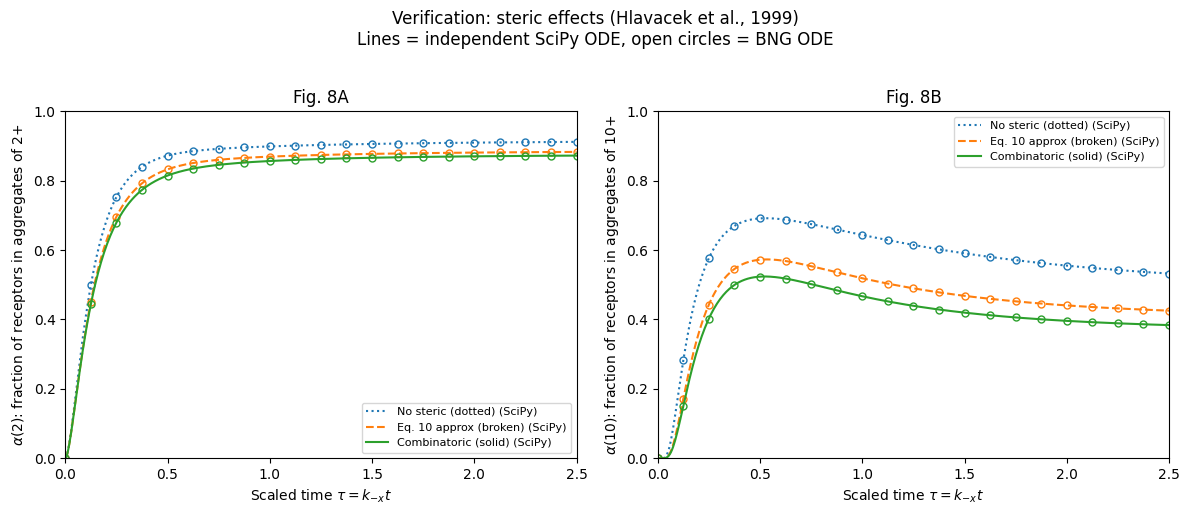

Saved verify_hlavacek1999.png


In [4]:
colors = {"nosteric": "C0", "eq10": "C1", "combinatoric": "C2"}
every = 25  # subsample BNG markers for visibility

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Panel A: alpha(2) ---
ax = axes[0]
for key, m in MODELS.items():
    R = results[key]
    c = colors[key]
    ax.plot(R["py_t"], R["py_a2"], color=c, ls=m["style"],
            lw=1.5, label=f'{m["label"]} (SciPy)')
    ax.plot(R["bng_t"][::every], R["bng_a2"][::every], "o",
            mfc="none", mec=c, ms=5)
ax.set_xlabel(r"Scaled time $\tau = k_{-x} t$")
ax.set_ylabel(r"$\alpha(2)$: fraction of receptors in aggregates of 2+")
ax.set_title("Fig. 8A")
ax.set_xlim(0, 2.5)
ax.set_ylim(0, 1)
ax.legend(fontsize=8)

# --- Panel B: alpha(10) ---
ax = axes[1]
for key, m in MODELS.items():
    R = results[key]
    c = colors[key]
    ax.plot(R["py_t"], R["py_a10"], color=c, ls=m["style"],
            lw=1.5, label=f'{m["label"]} (SciPy)')
    ax.plot(R["bng_t"][::every], R["bng_a10"][::every], "o",
            mfc="none", mec=c, ms=5)
ax.set_xlabel(r"Scaled time $\tau = k_{-x} t$")
ax.set_ylabel(r"$\alpha(10)$: fraction of receptors in aggregates of 10+")
ax.set_title("Fig. 8B")
ax.set_xlim(0, 2.5)
ax.set_ylim(0, 1)
ax.legend(fontsize=8)

fig.suptitle(
    "Verification: steric effects (Hlavacek et al., 1999)\n"
    "Lines = independent SciPy ODE, open circles = BNG ODE",
    fontsize=12, y=1.02,
)
fig.tight_layout()
plt.savefig("verify_hlavacek1999.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved verify_hlavacek1999.png")

## Error summary

In [5]:
print(f"{'Model':<20s} {'max|err| alpha_2':>18s} {'max|err| alpha_10':>18s}")
print("-" * 58)
for key, m in MODELS.items():
    R = results[key]
    print(f"{m['label']:<20s} {R['err_a2']:18.2e} {R['err_a10']:18.2e}")

tol = 1e-3
all_pass = all(
    R["err_a2"] < tol and R["err_a10"] < tol
    for R in results.values()
)
print(f"\nAll errors < {tol}? {'PASS' if all_pass else 'FAIL'}")

Model                  max|err| alpha_2  max|err| alpha_10
----------------------------------------------------------
No steric (dotted)             6.74e-07           8.82e-07
Eq. 10 approx (broken)           4.26e-07           7.41e-07
Combinatoric (solid)           4.70e-07           9.18e-07

All errors < 0.001? PASS
